#  Model Training Notebook

**Description**

This notebook includes training, test, and validation set creation and model training step. The model that is used in this project is U-Net with ResNet-50 backbone. The Pre-trained model is `ResNet50_Weights.SENTINEL2_ALL_MOCO` which is available in torchgeo library.

**Input folder(s)/file(s)**

2 files
- Public Urban Green Spaces (PUGS) ground truth (`dresden_pugs_gt.geojson`)
- Sentinel-2 image stack with PUGS OSM binary mask and SDT (clipped to Dresden boundary) (`stacked_sentinel2_dresden_clipped.geotiff`)

**Output folder(s)/file(s)**

3 folders and 2 files
- Output folder for image tiles of training set (`../data/processed/tiles/train`)
- Output folder for image tiles of test set (`../data/processed/tiles/test`)
- Output folder for image tiles of validation set (`../data/processed/tiles/val`)
- The best model checkpoint (example: `epoch=47-val_loss=0.18.ckpt`)
- Metrics file (CSV file) (`metrics.csv`)
- Hyperparmeters log file (`hparams.yaml`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- 1_data_acquisition_osm.ipynb
- 1_data_acquisition_satellite_image.ipynb
- 2_data_processing_osm.ipynb
- 2_data_processing_ground_truth.ipynb
- 3_data_processing_satellite_image.ipynb
- 5_ground_truth_creation.ipynb

**Note:** It does not require user to run `4_ground_truth_exploration.ipynb` notebook. The exploration notebook is created for understanding how each ground truth dataset complement each other and help author decide on which datasets will be used to create a final ground truth dataset.

In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

(Probably need to add model experiment table, how I select tiles, how to change the parameters?)

# Import libraries

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
import torch
from torchgeo.transforms import AugmentationSequential
from tqdm import tqdm
import kornia.augmentation as K
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from torchgeo.models import ResNet50_Weights
from torch.utils.data import DataLoader
from pugs_detection.raster import create_image_tiles
from pugs_detection.modeling.model import modify_first_layer
from pugs_detection.plots import plot_image_tiles, visualize_from_torchgeo_dataloader
from pugs_detection.modeling.segmentation_task import CustomSegmentationTask
from pugs_detection.utils import set_all_seeds
from pugs_detection.dataset import create_dataset_split

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information when converting to a PROJ string from another format.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired.*",
    category=UserWarning,
)

# Set seed to make it reproducible

In [4]:
# Set seeds for reproducibility
set_all_seeds(42)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


# Set variables

In [5]:
train_index_list = [2, 3, 9, 11, 12, 13, 15, 16, 18, 20, 23]
val_index_list = [7, 17, 19]
test_index_list = [8, 14, 22]
output_folder_path = "../data/processed/tiles"
image_path = "../data/processed/sentinel-2/stacked_sentinel2_dresden_clipped.geotiff"

# Define paths for pre-split tiles
train_image_path = "../data/processed/tiles/train"
val_image_path = "../data/processed/tiles/val"
test_image_path = "../data/processed/tiles/test"
# Vector data path
label_path = "../data/processed/ground truth/dresden_pugs_gt.geojson"

band_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]
num_channels = len(band_list)

# Model hyperparameters
batch_size = 16
loss_func = "focal"
lr = 0.0001
epochs = 50

# Logger path
logger_path = "../models"
sub_folder_name = "checkpoints"

# Create image tiles for training, validation, and test set

Manually specify tile

In [6]:
all_tiles_list = create_image_tiles(
    output_folder_path, image_path, train_index_list, val_index_list, test_index_list
)

Image bounds width: 27110.0 height: 22640.0
Tile dimensions width: 5422.0 height: 4528.0
Skipping tile 1: only 0.0% valid data
Tile 2 saved to train folder (44.4% valid data)
Tile 3 saved to train folder (85.5% valid data)
Skipping tile 4: only 7.0% valid data
Skipping tile 5: only 0.0% valid data
Skipping tile 6: only 13.3% valid data
Tile 7 saved to val folder (93.8% valid data)
Tile 8 saved to test folder (95.8% valid data)
Tile 9 saved to train folder (36.9% valid data)
Skipping tile 10: only 0.8% valid data
Tile 11 saved to train folder (59.9% valid data)
Tile 12 saved to train folder (100.0% valid data)
Tile 13 saved to train folder (100.0% valid data)
Tile 14 saved to test folder (98.8% valid data)
Tile 15 saved to train folder (54.1% valid data)
Tile 16 saved to train folder (77.8% valid data)
Tile 17 saved to val folder (100.0% valid data)
Tile 18 saved to train folder (99.7% valid data)
Tile 19 saved to val folder (92.3% valid data)
Tile 20 saved to train folder (35.7% valid 

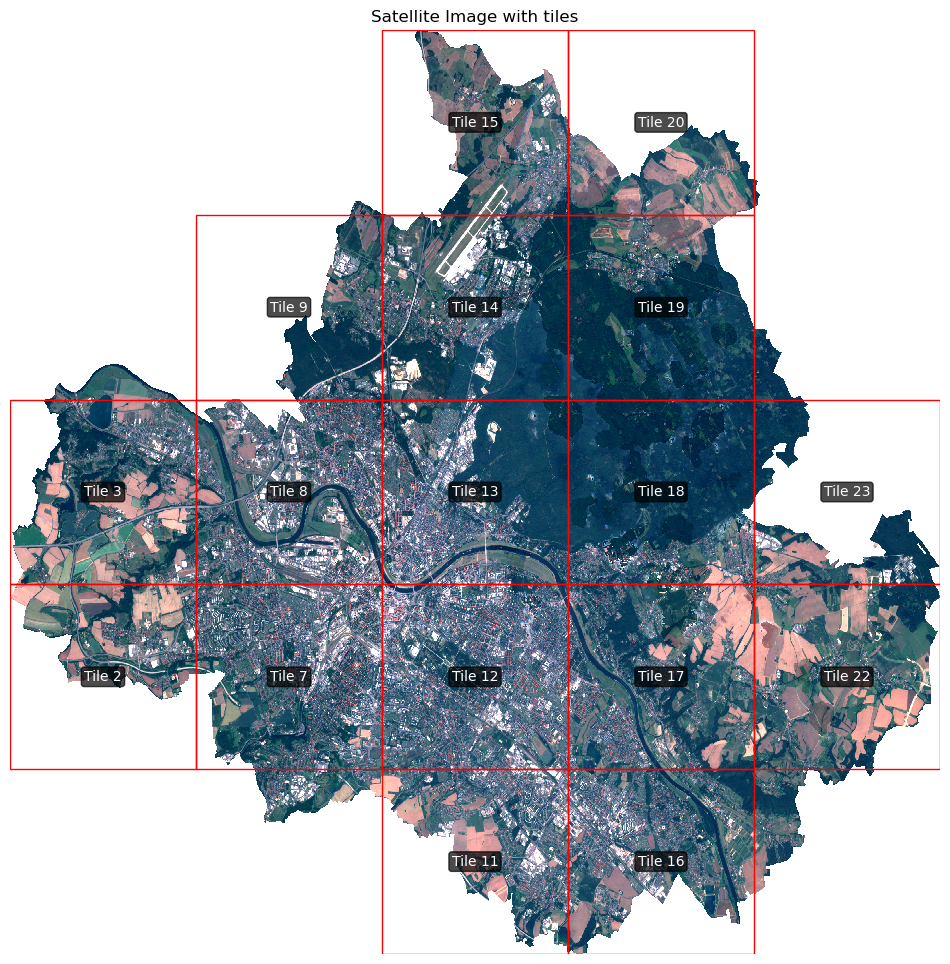

In [7]:
plot_image_tiles(image_path, all_tiles_list)

# Creating image patches

In [8]:
# Create specific augmentation transforms
h_flip_transform = AugmentationSequential(
    K.RandomHorizontalFlip(p=1.0), data_keys=["image", "mask"]
)

v_flip_transform = AugmentationSequential(
    K.RandomVerticalFlip(p=1.0), data_keys=["image", "mask"]
)

rotation_transform = AugmentationSequential(
    K.RandomRotation(degrees=45, p=1.0, align_corners=True), data_keys=["image", "mask"]
)

In [9]:
# Create list of specific transforms
transform_list = [h_flip_transform, v_flip_transform, rotation_transform]

## Create training dataset

In [10]:
# Create the filtered datasets
train_dataset = create_dataset_split(
    train_image_path, label_path, 32633, band_list, "train", transform_list
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
Filtering patches for train: 100%|██████████| 132/132 [00:31<00:00,  4.25patch/s]

Found 123 valid patches out of 132 total patches


In [11]:
print(len(train_dataset))

492


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=stack_samples,
    num_workers=4,
)

In [13]:
len(train_loader)

31

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.02


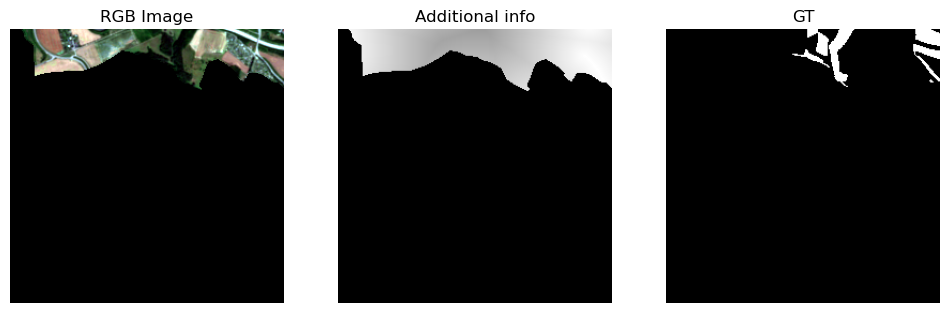

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.03


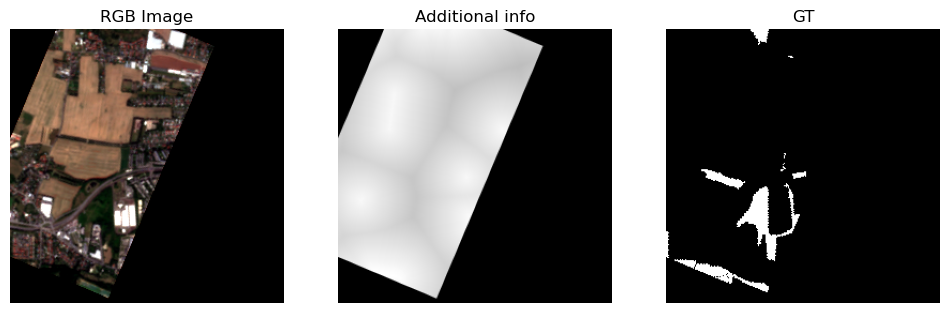

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.08


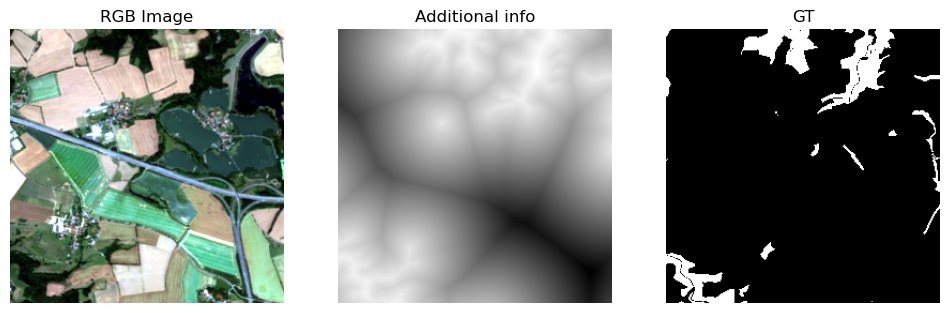

Sample 3:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.12


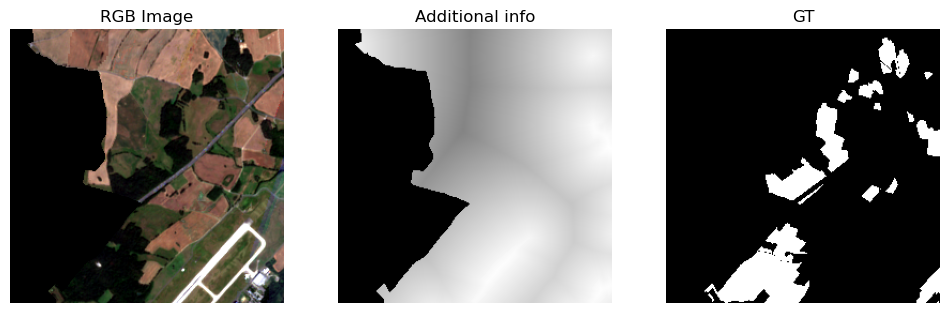

Sample 4:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.30


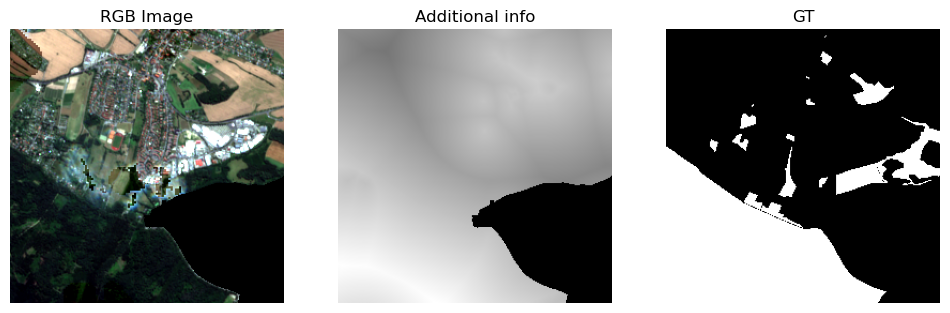

In [14]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(train_loader, 5, "additional", [13])
else:
    visualize_from_torchgeo_dataloader(train_loader, 5, "original")

## Create validation dataset

Set transform_sequence to None by default or optional params

In [15]:
val_dataset = create_dataset_split(
    val_image_path, label_path, 32633, band_list, "validation", None
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Using all 36 patches for validation set


In [16]:
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, collate_fn=stack_samples, num_workers=2
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.11


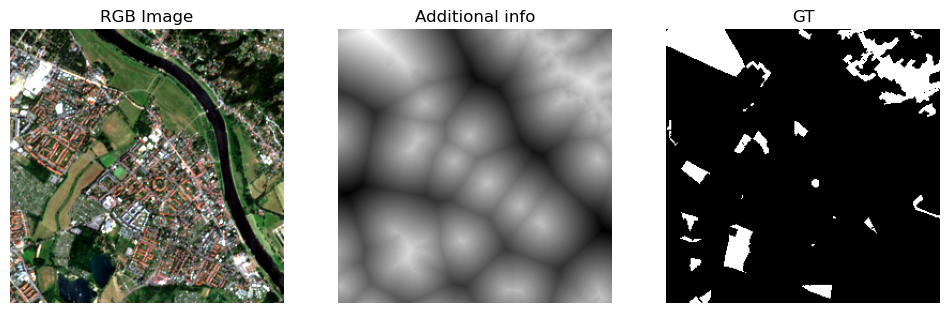

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.18


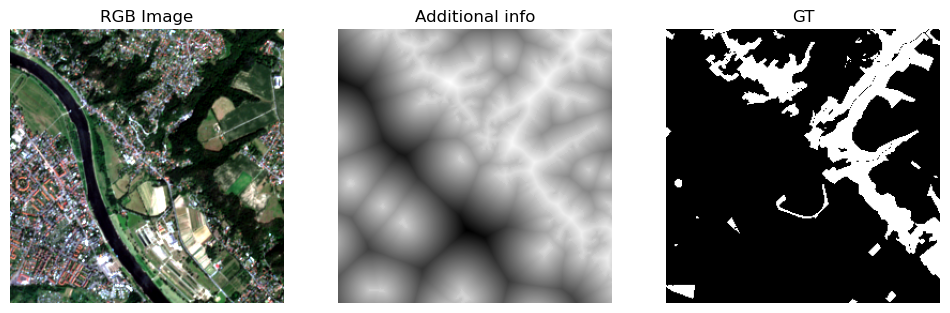

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.21


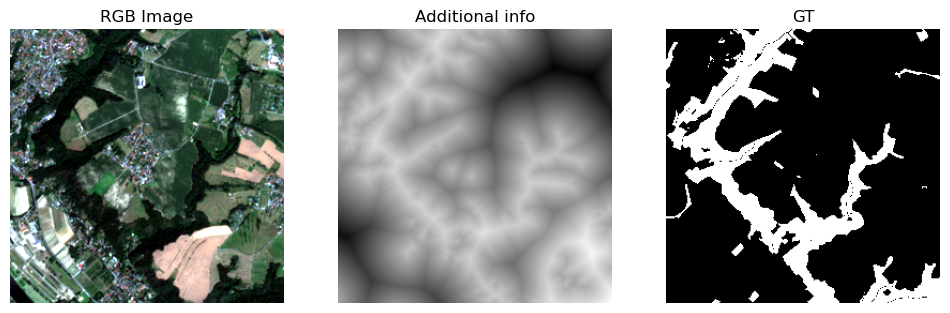

In [17]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(val_loader, 3, "additional", [13])
else:
    visualize_from_torchgeo_dataloader(val_loader, 3, "original")

## Create test dataset

Set transform_sequence to None by default or optional params

In [18]:
test_dataset = create_dataset_split(
    test_image_path, label_path, 32633, band_list, "test", None
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Using all 36 patches for test set


In [19]:
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, collate_fn=stack_samples, num_workers=1
)

In [20]:
len(test_loader)

3

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.39


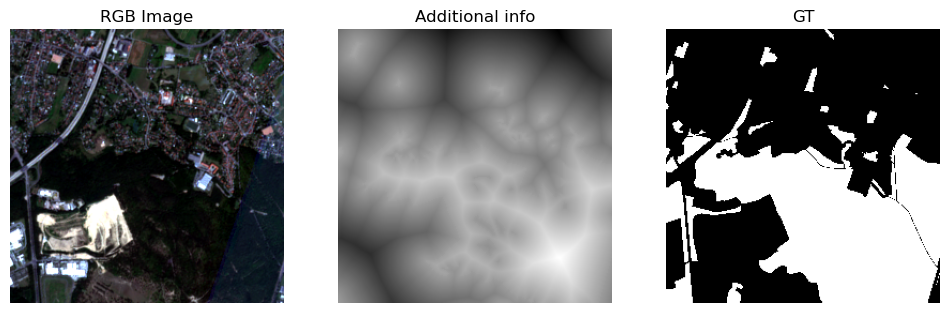

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.49


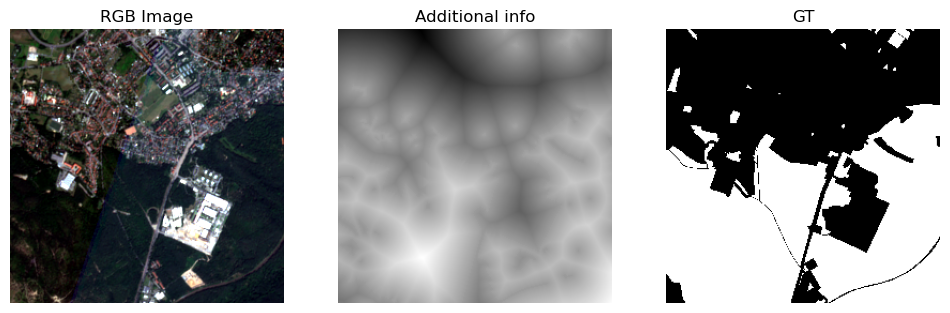

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.71


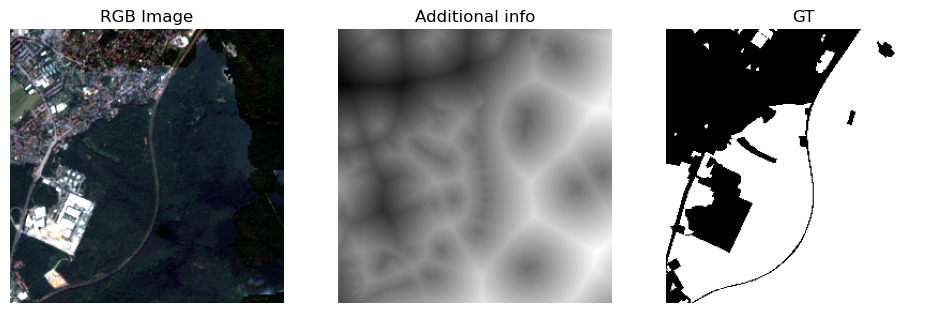

In [21]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(test_loader, 3, "additional", [13])
else:
    visualize_from_torchgeo_dataloader(test_loader, 3, "original")

# Create and train model

In [22]:
weight = ResNet50_Weights.SENTINEL2_ALL_MOCO

## Define Model

In [23]:
if num_channels > 13:
    task = CustomSegmentationTask(
        loss=loss_func,
        model="unet",
        backbone="resnet50",
        weights=weight,
        in_channels=13,
        num_classes=1,
        lr=lr,
        patience=5,
    )

    task = modify_first_layer(task, in_channels=num_channels)
else:
    task = CustomSegmentationTask(
        loss=loss_func,
        model="unet",
        backbone="resnet50",
        weights=weight,
        in_channels=num_channels,
        num_classes=1,
        lr=lr,
        patience=5,
    )

CustomSegmentationTask(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(14, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (re

## Training

In [24]:
checkpoint_callback = ModelCheckpoint(
    filename="{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=2,  # Save chckpoint with the best validation loss
    # every_n_epochs=5  # Save checkpoint every n epochs
)

In [25]:
early_stopping = EarlyStopping(monitor="val_loss", patience=10)

In [26]:
logger = CSVLogger(logger_path, name=sub_folder_name)

In [27]:
trainer = Trainer(
    max_epochs=epochs,
    deterministic=True,
    accelerator="cpu",
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [28]:
trainer.fit(model=task, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | Unet             | 32.6 M | train
1 | criterion     | FocalLoss        | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollection | 0      | train
4 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
32.6 M    Trainable params
0         Non-trainable params
32.6 M    Total params
130.222   Total estimated model params size (MB)
233       Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | Unet             | 32.6 M | train
1 | criterion     | FocalLoss        | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollec

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]